In [1]:
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.pyplot as plotter
import seaborn as sns

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
train_df = pd.read_csv("C://Users//User//Desktop//titles_data.csv", delimiter=';', skiprows=0, low_memory=False)
train_df

,titles,target
0,Родственник раскрыл настоящую фамилию Пугачёво...,1
1,Предсказания Матроны Московской на 2024-й год:...,1
2,"Пророчество схимонахини Нины об антихристе, ми...",1
3,«Думал об этом»: что Путин сказал о своем прее...,1
4,Путин поручил уведомить россиян об изменениях ...,1
...,...,...
3193,Путин поручил передать Республике Крым все акц...,0
3194,ЕК изучит просьбу Венгрии по нарушению Болгари...,0
3195,"Глава ""Россетей"" доложил Путину о достижении ц...",0
3196,"Платформа ""Мой экспорт"" научит устанавливать д...",0


In [3]:
train_df, test_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [4]:
train_df=train_df.reset_index(drop=True)
test_df=test_df.reset_index(drop=True)
train_df=train_df.rename(columns={"titles": "text", "target": "label"})
test_df=test_df.rename(columns={"titles": "text", "target": "label"})
display(train_df.head())
display(test_df.head())

,text,label
0,Шиитские вооруженные формирования обстреляли а...,0
1,Погибшего военкора Журавлева отметили литерату...,0
2,Кому пересчитают пенсию с 1 ноября: на индекса...,1
3,«Вылетела через окно»: страшная гибель жены из...,1
4,Депутат Ямпольская выразила соболезнования в с...,0


,text,label
0,"Режиссер Митта находится в реанимации, сообщил...",0
1,Испортится за несколько дней: никогда не храни...,1
2,Обладают антираковыми свойствами: эти продукты...,1
3,"Дед разрыдался, найдя тайник жены: что там ока...",1
4,Чеченец перешел на сторону ВСУ: что ему теперь...,1


In [5]:
display(train_df.nunique())
display(test_df.nunique())

text     2527
label       2
dtype: int64

text     637
label      2
dtype: int64

train


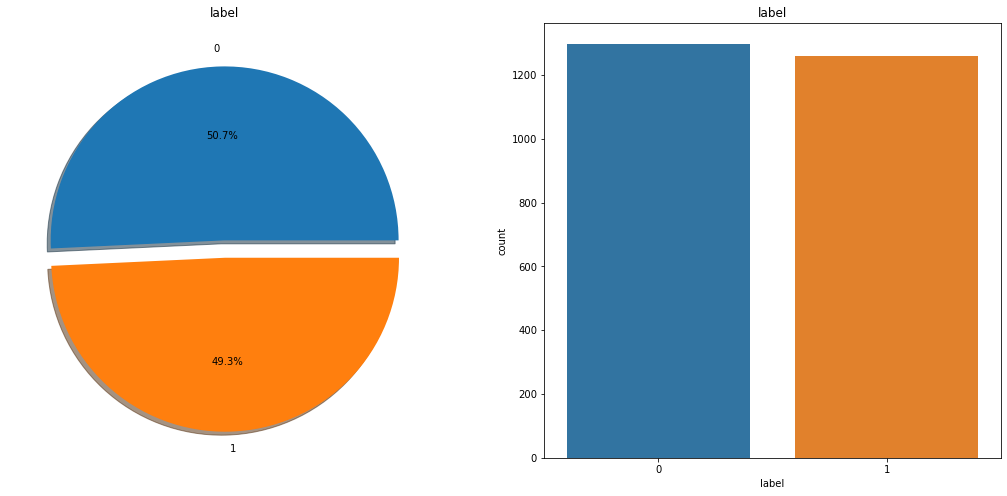

In [6]:
print("train")
f,ax=plt.subplots(1,2,figsize=(18,8))
train_df["label"].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('label')
ax[0].set_ylabel('')
sns.countplot(x = train_df["label"],ax=ax[1])
ax[1].set_title('label')
plt.show()

test


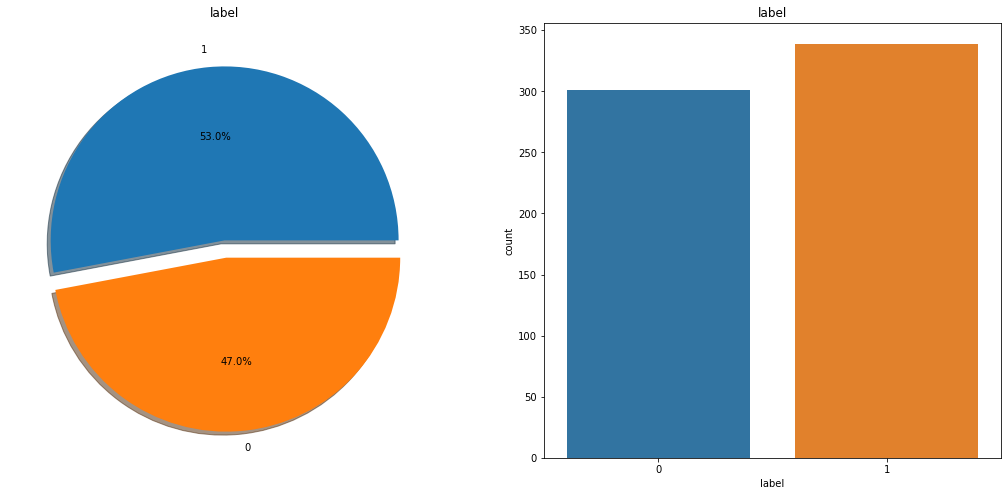

In [7]:
print("test")
f,ax=plt.subplots(1,2,figsize=(18,8))
test_df["label"].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('label')
ax[0].set_ylabel('')
sns.countplot(x = test_df["label"],ax=ax[1])
ax[1].set_title('label')
plt.show()

# Обработка

In [7]:
import string
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

In [8]:
with open("russian.txt", "r", encoding="utf-8") as file:
    stop_words = [line.strip() for line in file]

In [9]:
punctuations = string.punctuation

In [10]:
def remove_stopwords(text: str, words_to_remove: list) -> str:
    # Разбиваем текст на слова, учитывая апострофы и пунктуацию
    words = text.split()
    
    # Удаляем слова из списка (регистронезависимая проверка)
    filtered_words = [
        word for word in words 
        if word.lower() not in {w.lower() for w in words_to_remove}
    ]
    
    return " ".join(filtered_words)

def remove_chars_simple(text: str, chars: list) -> str:
    return ''.join([char for char in text if char not in chars])

def tokenize_words(text: str) -> list:
    g = word_tokenize(text)
    f = ""
    for i in g:
        f = f + " " +i
    return f[1:]

In [11]:
def process_text(text: str) -> str:
    # Пример обработки (замените на свою логику)
    processed = text.lower()  # Удаляем пробелы и приводим к нижнему регистру
    processed = remove_stopwords(processed, stop_words)
    processed = remove_chars_simple(processed, punctuations)
    processed = tokenize_words(processed)
    processed = " ".join(processed.split())  # Удаляем множественные пробелы
    return processed

In [12]:
train_df['tokenized_Text'] = train_df['text'].apply(process_text)

In [13]:
train_df

,text,label,tokenized_Text
0,Шиитские вооруженные формирования обстреляли а...,0,шиитские вооруженные формирования обстреляли а...
1,Погибшего военкора Журавлева отметили литерату...,0,погибшего военкора журавлева отметили литерату...
2,Кому пересчитают пенсию с 1 ноября: на индекса...,1,пересчитают пенсию 1 ноября индексацию рассчит...
3,«Вылетела через окно»: страшная гибель жены из...,1,« вылетела окно » страшная гибель жены известн...
4,Депутат Ямпольская выразила соболезнования в с...,0,депутат ямпольская выразила соболезнования свя...
...,...,...,...
2553,«Больше не наш»: российский певец привел в беш...,1,« больше наш » российский певец привел бешенст...
2554,Ну и вот и всплыла правда: что заявили в Гнеси...,1,всплыла правда заявили гнесинке shaman
2555,Задержан экс-боец ЧВК «Вагнер»: что вытворил с...,1,задержан эксбоец чвк « вагнер » вытворил супру...
2556,Что делали с пленными женщинами в годы Второй ...,1,делали пленными женщинами годы мировой


# CountVectorizer

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

In [9]:
X = train_df.iloc[:,0]
y = train_df.iloc[:,1]

In [10]:
vec = CountVectorizer()
X_vec = vec.fit_transform(X)

In [11]:
X_train, X_eval, y_train, y_eval = train_test_split(X_vec,y,test_size=0.2,stratify=y)

In [12]:
clf1 = KNeighborsClassifier()
clf2 = LogisticRegression()
clf3=  SVC()

In [13]:
eclf = VotingClassifier(estimators=[('KN', clf1),('LR', clf2),
                                    ('SVC', clf3)],voting='hard')

for clf, label in zip([clf1,clf2,clf3, eclf], 
                      ['KN','LR','SVC', 'Ensemble']):
    scores = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=5)
    print("accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

accuracy: 0.69 (+/- 0.03) [KN]
accuracy: 0.88 (+/- 0.02) [LR]
accuracy: 0.86 (+/- 0.02) [SVC]
accuracy: 0.87 (+/- 0.02) [Ensemble]


# TRAINING

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [15]:
Voting_model=eclf.fit(X_train, y_train)

In [16]:
y_pred_Voting = Voting_model.predict(X_eval)

Voting accuracy is: 84.961%


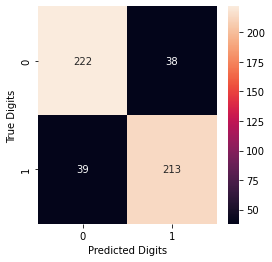

In [17]:
Voting_acc = accuracy_score(y_eval, y_pred_Voting)
print("Voting accuracy is: {0:.3f}%".format(Voting_acc * 100))
cm = confusion_matrix(y_eval, y_pred_Voting)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='.0f')
plt.xlabel("Predicted Digits")
plt.ylabel("True Digits")
plt.show()

# TF-IDF

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
X = train_df.iloc[:,0]
y = train_df.iloc[:,1]

In [22]:
vec = TfidfVectorizer()
X_vec = vec.fit_transform(X)

In [23]:
X_train, X_eval, y_train, y_eval = train_test_split(X_vec,y,test_size=0.2,stratify=y)

In [24]:
clf1 = KNeighborsClassifier()
clf2 = LogisticRegression()
clf3=  SVC()

In [25]:
eclf_tfidf = VotingClassifier(estimators=[('KN', clf1),('LR', clf2),
                                    ('SVC', clf3)],voting='hard')

for clf, label in zip([clf1,clf2,clf3, eclf], 
                      ['KN','LR','SVC', 'Ensemble']):
    scores = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=5)
    print("Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

Accuracy: 0.85 (+/- 0.02) [KN]
Accuracy: 0.87 (+/- 0.01) [LR]
Accuracy: 0.88 (+/- 0.02) [SVC]
Accuracy: 0.87 (+/- 0.01) [Ensemble]


# Training

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

In [27]:
Voting_model=eclf_tfidf.fit(X_train, y_train)

In [28]:
y_pred_Voting = Voting_model.predict(X_eval)

Voting accuracy is: 90.820%


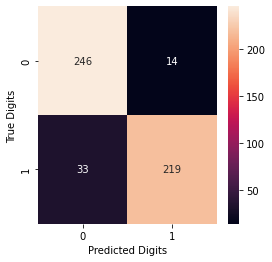

In [29]:
Voting_acc = accuracy_score(y_eval, y_pred_Voting)
print("Voting accuracy is: {0:.3f}%".format(Voting_acc * 100))
cm = confusion_matrix(y_eval, y_pred_Voting)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='.0f')
plt.xlabel("Predicted Digits")
plt.ylabel("True Digits")
plt.show()